# Balanced Portfolio Asset Allocation with Sckit-Learn and PyTorch

* Date: March 2026
* Author: Andrew Muschamp McKay
* Email: [andrew@muschamp.ca](mailto:andrew@muschamp.ca)
* Web: [www.muschamp.ca](https://www.muschamp.ca/)

## Abstract

The 60% equity and 40% debt portfolio is a classic of the asset management industry and retirement planning for generations. Although there a proven benefits to diversification and choosing assets which have an uncorrelated time series of daily price or return movements. Simply using a heuristic or rule-of-thumb to allocate client assets is not always optimal. So continuing on from the Python for Asset Management class and the Reinforcement Learning for Finance class and book in the [Python for Finance](https://python-for-finance.com) certificate program, Scikit_Learn and PyTorch were employed to see if machine learning could allocate assets more effectively.

Clients often have an an Investment Policy Statement (IPS) which details which assets they are willing to hold and in what proportion. This can be modeled in Python and an Investing Agent can be made to adhere to these pre-determined boundaries. Success will be determined primarily by the Sharpe Ratio which combines risk and return into a single number **where a larger number is clearly better**. Can the Investing Agent beat the average 60:40 portfolio, can it beat the benchmark detailed in the IPS? 

*Let's find out.*

The assets chosen are publicly available in Canada and the prices and returns used are calculated by State Street. 

### Imports

These are the most commonly required imports, these libraries may have additional libraries they rely on. They are all present in Google Colab. However, Google Colab required changing how and what order I import various libraries I even needed to install an additional library I added to the project called `pandas_market_calendars`. Beyond that library the others are all very standard `pandas` for panel data, `numpy` for additional mathematical horsepower. `math` and `datetime` are standard Python packages which are used for calculations over time. `pylab` contains `matplotlib` which is used for graphing.

As can be guessed by the title, the implmentation relies heavily on **Scikit-Learn** and **PyTorch** to do artificial intelligence and machine learning, specifically Deep Q-Learning as covered in the course and associated books.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math 
import seaborn as sns
from datetime import datetime

### Settings
Here we can set some global options.

In [9]:
# For Google Colab smaller graphs and smaller legends proved adviseable
plt.style.use('seaborn-v0_8')
# Filtering warnings can be undone for debugging
import warnings
warnings.filterwarnings('ignore')

### Additional Installation of Python Package
I added `pandas_market_calendars` so I need to install it on Google Colab. This library lets you determine local trading days and will help future proof the code.

In [11]:
!pip install pandas_market_calendars

### Mean Variance Portfolio Class
This class represents a portfolio of investable assets. It can accept a benchmark, comparison portfolios, and boundaries or limits that are followed when optimizing the portfolio for Sharpe Ratio a measure of risk adjusted reward. This class also has many support methods to enable visualizing and comparing portfolios.

It is hosted on GitHub and must be fetched from that online code repository.

In [13]:
!wget https://raw.githubusercontent.com/muskie/cpf/main/mvportfolio.py
from mvportfolio import MVPortfolio

zsh:1: command not found: wget


### Deep Q Learning Agent
This class is based on the one presented in [Reinforcement Learning for Finance](https://certificate.tpq.io/rlfinance.html). It uses PyTorch and provides the neural network used by the Investing Agent to navigate the Investing Environment and fascilitate portfolio optimization.

It is also hosted on GitHub and must be fetched from that online code repository.

In [15]:
!wget https://raw.githubusercontent.com/muskie/cpf/main/dqlagent_pytorch.py
from dqlagent_pytorch import *

zsh:1: command not found: wget


### Asset Alllocation Investing Environment and Agent
This is the class that uses Deep Q-Learning and a neural network to allocate assets. It uses PyTorch as well as Scikit-Learn to accomplish this.

It too is hosted on GitHub and must be fetched from that online code repository.

In [17]:
# I revised Investing and InvestingAgent heavily it now works for n assets at least small n's.
!wget https://raw.githubusercontent.com/muskie/cpf/main/assetallocation_pytorch.py
from assetallocation_pytorch import * # was Investing and InvestingAgent

zsh:1: command not found: wget


In [18]:
# This is better when developing, as long as you include the above cells Google Colab will tolerate this
%run mvportfolio.py 

### Helper Functions

These are some helper functions used to load and split the data into training and testing subsets.

In [21]:
def get_log_returns_from_csv(path, rplr='r'):
    # Using returns is better than prices for assets with a fixed price and variable return
    if(rplr == 'p'):
        # This is a csv file of prices
        raw = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
        rets = rets = np.log(raw / raw.shift(1)).dropna()
    elif(rplr == 'lr'):
        # This is in case you have long returns already in csv
        rets = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
    else:
        # This is preferred over prices
        raw = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
        rets = np.log(1 + raw)
    return rets

def train_test_split_by_date(rets, split_date):
    training_returns = rets[:split_date]
    testing_returns = rets[split_date:]
    return training_returns, testing_returns

## Data

Normally cleaning data is a significant amount of work. In our case the data (returns) were chosen to go between two dates and the benchmark returns also go between those two dates. *The returns are Gross of fees and in Canadian dollars.* The benchmark returns are monthly early in the time series which causes a less smooth graph, but given we have over 2000 daily returns, we should be fine. This set represents real asset class returns at an investment management firm competing against a balanced benchmark consisting of:

**From Jun 2021:**
- 5% FTSE Canada 91 Day TBill Index
- 35% FTSE Canada Universe Bond 
- 15% S&P/TSX Composite
- 7.5% S&P/TSX Small Cap 
- 15% S&P 500 
- 15% MSCI ACWI ex-USA (net) 
- 7.5% MSCI ACWI Small Cap (net)

**From Oct 2016:**
- 5% FTSE Canada 91 Day Treasury Bill
- 30% FTSE Canada Universe Bond
- 5% FTSE WGBI
- 15% S&P/TSX Composite
- 7.5% S&P/TSX Small Cap
- 15% S&P 500
- 15% MSCI ACWI ex-USA (net)
- 7.5% MSCI ACWI Small Cap (net)

The code was tested with other data and should be data agnostic, but typically balanced portfolios can range from 20% bonds to 80% bonds with the classic 60:40 equity to debt ratio being most common. Up to 5% cash or near cash (T-bills) is not uncommon, but you could go higher maybe up to 20% and still be considered a balanced portfolio.

This data is stored in two `csv` files hosted on a website other than GitHub.

In [26]:
path = 'https://www.muschamp.ca/OffSite/eightAssetReturns.csv'
bm_path = 'https://www.muschamp.ca/OffSite/benchmarkReturns.csv'

In [27]:
log_returns = get_log_returns_from_csv(path)

In [28]:
first_date = log_returns.index[0]
last_date = log_returns.index[-1]
print(f"Data is from {first_date} to {last_date}")

Data is from 2017-02-01 00:00:00 to 2025-12-31 00:00:00


**This is about eight years of data**, so we'll put aside two years for later testing and use the rest for training and exploration.

In [30]:
split_date = log_returns.index[-504] + pd.Timedelta(days=1) # This splits at two years of trading days plus one
# split_date = '2024-01-01' # This does the same thing, New Year's Day is helpfully a non-trading day.
print(split_date)

2023-12-30 00:00:00


In [31]:
training_asset_returns, testing_asset_returns = train_test_split_by_date(log_returns, split_date)

### A Portfolio needs a Benchmark
The carefully chosen benchmark, provides our balanced portfolios and algorithm something to compete against. The benchmark was chosen before assets weights were determined and the Investing Agent is unaware of the existance of this benchmark. This means the Investing Agent is benchmark agnostic, however many clients are not.

In [33]:
bm_log_returns = get_log_returns_from_csv(bm_path)

In [34]:
bm_training_returns, bm_testing_returns = train_test_split_by_date(bm_log_returns, split_date)

In [35]:
print(len(training_asset_returns) == len(bm_training_returns))
print(len(testing_asset_returns) == len(bm_testing_returns))
print(testing_asset_returns.index[0] == bm_testing_returns.index[0])
print(training_asset_returns.index[-1] == bm_training_returns.index[-1])

True
True
True
True


**So the benchmark is the same length as the training asset returns and is split the same way.**

### Asset Returns and Correlations

These returns are published daily and calculated by State Street you can see positive correlations between Canadian Large Cap equity (E-CLC) and Canadian Small Cap equity (E-CSC) for instance. You can see how both the bond sleeve and the money market instruments are negatively correlated with the equity assets classes. Over the last few years you can see U.S. equity has done better than other asset classes.

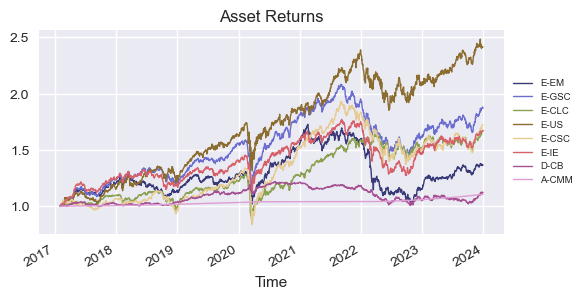

In [39]:
training_asset_returns.cumsum().apply(np.exp).plot(title="Asset Returns", 
                                                   xlabel="Time",
                                                   lw=1,
                                                   figsize=(6, 3),
                                                   cmap='tab20b')
plt.legend(loc='center left', fontsize='x-small', bbox_to_anchor=(1, 0.5));

In [40]:
corr_matrix = training_asset_returns.corr()
corr_matrix.style.background_gradient(cmap='coolwarm').format(precision=4).set_caption("Asset Correlations")

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM
E-EM,1.0000,0.5482,0.3917,0.3294,0.3960,0.6328,0.0371,-0.0267
E-GSC,0.5482,1.0000,0.6464,0.5658,0.6459,0.8503,0.1112,-0.0199
E-CLC,0.3917,0.6464,1.0000,0.7396,0.8366,0.6117,-0.0275,-0.0171
E-US,0.3294,0.5658,0.7396,1.0000,0.6255,0.5261,-0.0034,-0.0241
E-CSC,0.3960,0.6459,0.8366,0.6255,1.0000,0.5743,0.0394,-0.0207
E-IE,0.6328,0.8503,0.6117,0.5261,0.5743,1.0000,0.0981,-0.0148
D-CB,0.0371,0.1112,-0.0275,-0.0034,0.0394,0.0981,1.0000,-0.0128
A-CMM,-0.0267,-0.0199,-0.0171,-0.0241,-0.0207,-0.0148,-0.0128,1.0000


## Mean-Variance Portfolio 

My mean-variance portfolio calculating class is based on the one created during the program but is informed by how balanced portfolios are constructed and managed at our firm. We have a fixed income team that manages bonds and t-bills so most of the portfolio construction and optimization comes from setting the equity weight and choosing which equity strategies to include in the portfolio. Each equity strategy consists of 50+ equity securities in an actively management portfolio. I provide a variety of options including the ability to compare against other predetermined asset weights, compete against a benchmark, and if you choose extremely specific boundaries these can override the minimum and maximum individual asset weights and the target asset class weights. Setting the boundaries directly allows for the most detailed testing and graphing. 

*Only the returns are required to initiate the class.*

#### Balanced Portfolios
Although the classic definition of a balanced portfolio is 60% Equity and 40% Bonds, that definition is too narrow for some. At our firm a Conservative Balanced Portfolio could have closer to 60% Bonds and T-Bills and a Growth Oriented Balanced Portfolio could have up to 80% Equity. Alternative assets such as Private Equity or other illiquide assets are potentially included in custom balanced portfolios. These can be difficult to optimize for as the assets are not marked to market daily. No ill-liquid assets are included in our training and testing data sets.

#### Custom Boundaries
Limiting the algorithm's ability to assign too much of the portfolio to a single security or asset class can be simulated in infinite variety. There is only one bond sleeve so generally allowing a wider range in that sleeve is how you can simulate between 20% and 80% bonds. For equity positions a range between zero and a third of the portfolio was used extensively in testing. *However, this was chosen arbitrarily and is not firm policy.*

#### Sample Portfolio Weights
I've included a number of arbitrary but illustrative asset weights. These include a classic 60:40 balanced portfolio which I allow to have 1% T-Bills. A 40:60 portfolio and an 80:20 portfolio are included in our training as well as a more income focused portfolio. You can use whatever weights you think are intuitive based on the returns and correlations above. Your weights ***must*** sum to 1 or you will instead get an equal weight portfolio.

An equal weight portfolio is always a good idea to test and train agaist. So I always include an equal weight portfolio so you don't need to specify one when initiating your Mean Variance Portfolio class.

In [43]:
# The boundaries aka the range of weights assignable to each asset is a key factor in algorithm asset allocation
# Boundary order EM, GSC, CLC, US, CSC, IE, CB, CMMM
custom_bnds = ((.0, .33), (.0, .33), (.0, .33), (.0, .33), (.0, .33), (.0, .33), (.19, .6), (.01, .2))

In [44]:
# We can have up to five sets of comparison portfolio weights.
# Boundaries are not enforced on them, but in the spirit of fairness they should be adhered to.
portfolio_one_weights = (.10, .10, .10, .10, .10, .10, .39, .01) 
portfolio_one_name = 'Classic 60:40'
portfolio_two_weights = (.0659, .0659, .0659, .0659, .0659, .0659, .59, .0146) 
portfolio_two_name = 'Conservative 40:60'
portfolio_three_weights = (.133, .133, .133, .133, .133, .133, .19, .012) 
portfolio_three_name = 'Equity Growth 80:20'
portfolio_four_weights = (.05, .05, .05, .05, .05, .05, .6, .10) 
portfolio_four_name = 'Income Focused'
portfolio_five_weights = (.05, .05, .125, .125, .05, .2, .37, .03) 
portfolio_five_name = 'Intuitive Weights'

In [45]:
symbols = training_asset_returns.columns # This is the entire universe of assets, you can use a subset too
# custom_min = 0.03 # zero is default, but can be overriden
# custom_max = 0.6 # one is default, but can be overriden
# target_asset_classes = [0.6, .37, .03] # 60 equity and 40 debt is the defualt
# As we set custom_bnds above, this overrides asset class weights and min and max position size
# Setting your own custom boundaries is the most granular level of control.
training_portfolios = MVPortfolio(
                                    # min_largest_asset_class_position_size=custom_min, 
                                    # max_largest_asset_class_position_size=custom_max,
                                    # asset_class_weights=target_asset_classes,
                                    bm_returns=bm_training_returns,
                                    comparison_weights_one=portfolio_one_weights,
                                    portfolio_one_name=portfolio_one_name,
                                    comparison_weights_two=portfolio_two_weights,
                                    portfolio_two_name=portfolio_two_name,
                                    comparison_weights_three=portfolio_three_weights,
                                    portfolio_three_name=portfolio_three_name,
                                    comparison_weights_four=portfolio_four_weights,
                                    portfolio_four_name=portfolio_four_name,
                                    comparison_weights_five=portfolio_five_weights,
                                    portfolio_five_name=portfolio_five_name,
                                    boundaries=custom_bnds,
                                    universe=training_asset_returns,
                                    holdings=symbols
                                   )

Remember target asset class weights [0.6, 0.4, 0.0] can be overruled by bnds.
Current bnds are ((0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.19, 0.6), (0.01, 0.2))


In [46]:
bnds_used_in_training = training_portfolios.bnds # Save for later
# print(bnds_used_in_training)

#### Equal Weight Portfolio Weights
The displayed weights are rounded to four decimal places but internally they are not rounded. They are floating point numbers. The equal weight portfolio ends up with 25% of the assets in bonds and money market instruments so it is on the lower end of our definition of a balanced portfolio. This is advantagous compared to the benchmark weights.

In [48]:
equal_weights = training_portfolios.equal_weights
training_portfolios.dataframe_for_weights(equal_weights)

,Weight
Asset,
E-EM,0.125
E-GSC,0.125
E-CLC,0.125
E-US,0.125
E-CSC,0.125
E-IE,0.125
D-CB,0.125
A-CMM,0.125


#### Minimum Risk Portfolio Weights

The minimum risk portfolio weights are determined, primarily to draw the efficient frontier it is unlikely a customer would choose this portfolio, however some customers are risk adverse and this portfolio maxes out bonds and money market instruments algorithmicly.

In [51]:
minimum_risk_weights = training_portfolios.minimum_risk_portfolio()
training_portfolios.dataframe_for_weights(minimum_risk_weights)

,Weight
Asset,
E-EM,8.16800e-02
E-GSC,3.40393e-02
E-CLC,6.92131e-02
E-US,5.13543e-03
E-CSC,4.39102e-18
E-IE,9.93223e-03
D-CB,6.00000e-01
A-CMM,2.00000e-01


#### Maximum Sharpe Portfolio Weights

This is the most efficient portfolio possible giving the time frame and assets and returns provided.

In [54]:
maximum_sharpe_weights = training_portfolios.maximum_sharpe_portfolio()
training_portfolios.dataframe_for_weights(maximum_sharpe_weights)

,Weight
Asset,
E-EM,1.76127e-16
E-GSC,2.68920e-01
E-CLC,3.85997e-16
E-US,1.72818e-01
E-CSC,6.08596e-17
E-IE,2.58564e-16
D-CB,3.58262e-01
A-CMM,2.00000e-01


#### Maximum Return portfolio weights given limits set above

This is the portfolio that provides the highest return while still being on the efficient frontier. Many clients may initially prefer this portfolio until they realize with greater returns come greater volatility.

In [57]:
maximum_return_weights = training_portfolios.maximum_return_portfolio()
training_portfolios.dataframe_for_weights(maximum_return_weights)

,Weight
Asset,
E-EM,2.70996e-17
E-GSC,3.30000e-01
E-CLC,9.58435e-17
E-US,3.30000e-01
E-CSC,1.40000e-01
E-IE,0.00000e+00
D-CB,1.90000e-01
A-CMM,1.00000e-02


### Visualizing Portfolios
Given various portfolios, we can relatively quickly produce the efficient frontier given the boundaries and limits set above. The sample portfolios, equal weight portfolio, and benchmark portfolio risk return characteristics can be compared to the maximum sharpe portfolio and minimum risk portfolio graphically.

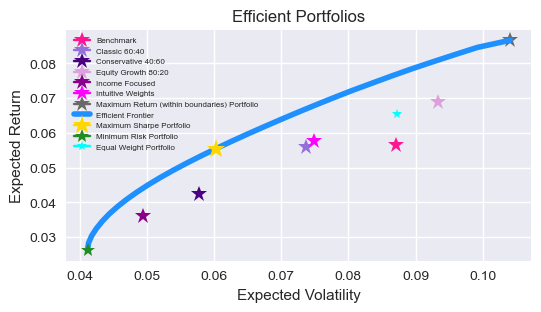

In [59]:
training_portfolios.visualize_efficient_frontier() 

### One Year of Cummulative Equal Weight Portfolio Returns

2023-01-01 00:00:00


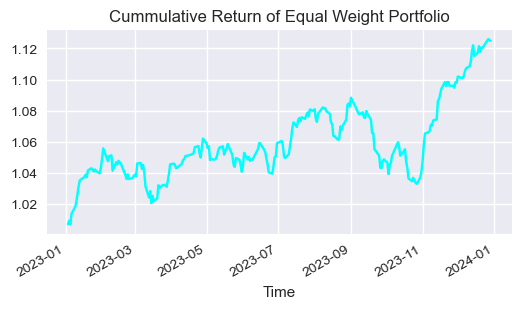

In [61]:
period_start = split_date + pd.Timedelta(days=-363) # This subtracts calendar days to get January 1st.
print(period_start)
cum_returns = training_portfolios.cummulative_portfolio_returns(weights=training_portfolios.equal_weights,
                                                                start_date=period_start, 
                                                                end_date=split_date)
cum_returns.plot(title="Cummulative Return of Equal Weight Portfolio",
                 color="cyan",
                 figsize=(6, 3),
                 xlabel="Time");

### One Year of Cummulative Benchmark Returns

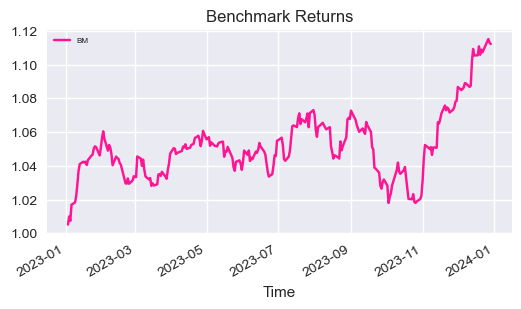

In [63]:
training_portfolios.bm_returns[period_start:split_date].cumsum().apply(np.exp).plot(title="Benchmark Returns",
                                                                                    color="deeppink",
                                                                                    figsize=(6, 3),
                                                                                    xlabel="Time");

### Cummulative Returns of various portfolio
There is a method to visualize all the cummulative returns of various portfolios either between two dates or over the entire training period.

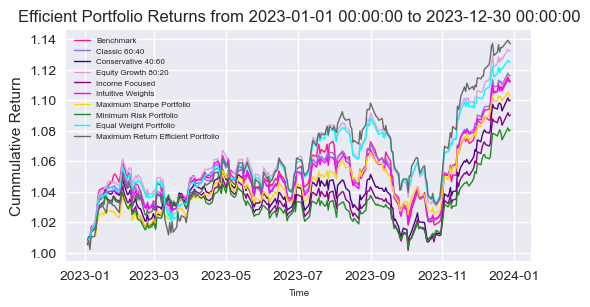

In [65]:
training_portfolios.visualize_portfolio_returns(start_date=period_start, end_date=split_date) # One Year

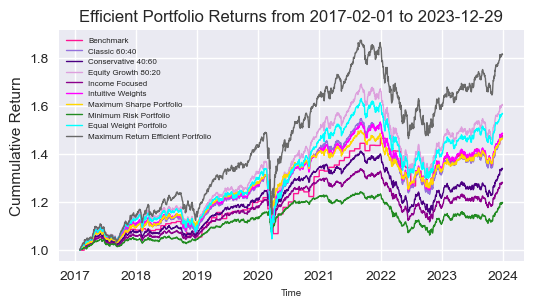

In [66]:
training_portfolios.visualize_portfolio_returns() # Entire training period

#### Maximum Return Portfolio
As you can see for both the entire training period and a sample year the maximum return portfolio performs the best. However, this portfolio may take on more risk than a client can tolerate, but it demonstrates the efficient frontier's accuracy.

## Calculating Calendar Year Mean-Variance Portfolios
It is possible to split the training data into smaller subsets to get the mean-variance portfolio for individual years this is anagolous to performing annual rebalancing based on reviewing the previous year's returns. Basing your portfolio on the previous year's returns may not be as effective as choosing weights based on a longer time period, but it may also prove advantageous, *lets try*.

In [69]:
optimal_yearly_weights = training_portfolios.calendar_year_maximum_sharpe_portfolios()

In [70]:
training_portfolios.pretty_yearly_weights(optimal_yearly_weights)

+------+---------+---------+
| Year | Holding | Weights |
+------+---------+---------+
| 2018 |   E-EM  |   0.0   |
| 2018 |  E-GSC  |   0.0   |
| 2018 |  E-CLC  |   0.0   |
| 2018 |   E-US  |   0.2   |
| 2018 |  E-CSC  |   0.0   |
| 2018 |   E-IE  |   0.0   |
| 2018 |   D-CB  |   0.6   |
| 2018 |  A-CMM  |   0.2   |
|      |         |         |
| 2019 |   E-EM  |   0.0   |
| 2019 |  E-GSC  |   0.15  |
| 2019 |  E-CLC  |   0.02  |
| 2019 |   E-US  |   0.0   |
| 2019 |  E-CSC  |   0.27  |
| 2019 |   E-IE  |   0.0   |
| 2019 |   D-CB  |   0.35  |
| 2019 |  A-CMM  |   0.2   |
|      |         |         |
| 2020 |   E-EM  |   0.17  |
| 2020 |  E-GSC  |   0.0   |
| 2020 |  E-CLC  |   0.0   |
| 2020 |   E-US  |   0.03  |
| 2020 |  E-CSC  |   0.0   |
| 2020 |   E-IE  |   0.0   |
| 2020 |   D-CB  |   0.6   |
| 2020 |  A-CMM  |   0.2   |
|      |         |         |
| 2021 |   E-EM  |   0.0   |
| 2021 |  E-GSC  |   0.0   |
| 2021 |  E-CLC  |   0.33  |
| 2021 |   E-US  |   0.18  |
| 2021 |  E-CS

### How did we do?
We can go through each complete calendar year in our training data set and see how well the previous year's mean variance portfolio would have done if we had rebalanced annually.

In [72]:
year_one = list(optimal_yearly_weights)[0]
last_year = list(optimal_yearly_weights)[-1]
yearly_test_results = pd.DataFrame()
for year in range(year_one, last_year):
    rets_ = training_portfolios.our_returns[symbols].loc[f'{year}-01-01':f'{year}-12-31']
    epv = MVPortfolio.annualized_volatility(rets_, optimal_yearly_weights[year])
    epr = MVPortfolio.annualized_return(rets_, optimal_yearly_weights[year])
    esr = epr / epv
    rets_ = training_portfolios.our_returns[symbols].loc[f'{year + 1}-01-01':f'{year + 1}-12-31']
    rpv = MVPortfolio.annualized_volatility(rets_, optimal_yearly_weights[year])
    rpr = MVPortfolio.annualized_return(rets_, optimal_yearly_weights[year])
    rsr = rpr / rpv
    yearly_test_results = pd.concat([yearly_test_results, pd.DataFrame({'Expected Portfolio Volatility': epv, 
                                                                        'Expected Portfolio Return': epr, 
                                                                        'Expected Sharpe Ratio': esr,
                                                                        'Realized Portfolio Volatility': rpv, 
                                                                        'Realized Portfolio Return': rpr, 
                                                                        'Realized Sharpe Ratio': rsr},
                                                                       index=[year + 1])])
yearly_test_results 

,Expected Portfolio Volatility,Expected Portfolio Return,Expected Sharpe Ratio,Realized Portfolio Volatility,Realized Portfolio Return,Realized Sharpe Ratio
2019,0.03543,0.03200,0.90305,0.03111,0.09286,2.98506
2020,0.03046,0.14095,4.62805,0.10489,0.10909,1.04005
2021,0.04727,0.09359,1.98008,0.03728,-0.00468,-0.12555
2022,0.06151,0.12791,2.07958,0.10040,-0.07639,-0.76081
2023,0.10391,-0.06850,-0.65930,0.05983,0.09654,1.61356


### How did we do on average?

In [74]:
yearly_test_results.mean()

Expected Portfolio Volatility    0.05571
Expected Portfolio Return        0.06519
Expected Sharpe Ratio            1.78629
Realized Portfolio Volatility    0.06670
Realized Portfolio Return        0.04348
Realized Sharpe Ratio            0.95046
dtype: float64

### Visualizing Annual Mean Variance Portfolio Predictions

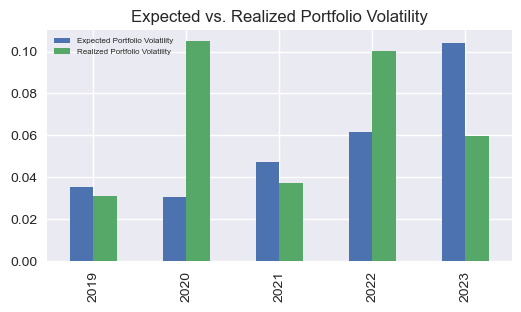

In [76]:
yearly_test_results[['Expected Portfolio Volatility', 
                     'Realized Portfolio Volatility']].plot(kind='bar', 
                                                            figsize=(6, 3),
                                                            title= 'Expected vs. Realized Portfolio Volatility');

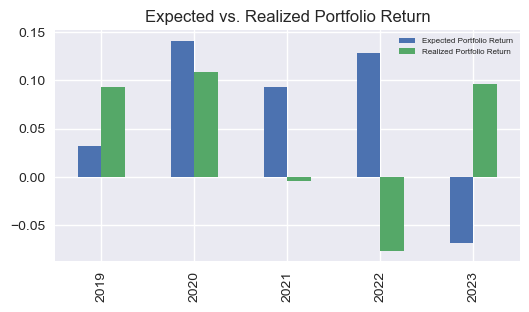

In [77]:
yearly_test_results[['Expected Portfolio Return', 
                     'Realized Portfolio Return']].plot(kind='bar', 
                                                        figsize=(6, 3),
                                                        title= 'Expected vs. Realized Portfolio Return');

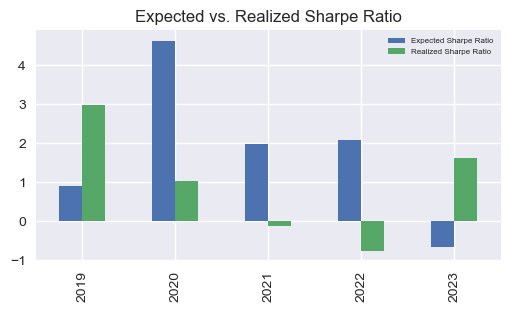

In [78]:
yearly_test_results[['Expected Sharpe Ratio', 
                     'Realized Sharpe Ratio']].plot(kind='bar', 
                                                    figsize=(6, 3),
                                                    title= 'Expected vs. Realized Sharpe Ratio');

#### Let's save the last training year's optimal weights

In [80]:
last_training_years_optimal_weights = optimal_yearly_weights[last_year]
training_portfolios.dataframe_for_weights(last_training_years_optimal_weights)

,Weight
Asset,
E-EM,0.32708
E-GSC,0.02933
E-CLC,0.00000
E-US,0.17322
E-CSC,0.01781
E-IE,0.06257
D-CB,0.19000
A-CMM,0.20000


# Can Artificial Intelligence do better?
**Is it possible to choose better portfolio weights using artificial intelligence?** Specifically we will use reinforcement learning combined with a neural network. This is known as Deep Q-Learning. The investing agent has the same goal of lowering volatility and increasing returns to achieve superior risk adjusted returns. An investing environment is set up with the same assets and boundaries affecting how much can be invested in individual assets by the Agent. *Prices are used instead of log returns and the returns are normalized as neural networks are sensitive to the scale of the data they work with.*

The Agent will be given a random set of consective daily closing prices and using that data will attempt to optimize the portfolio reviewing the data and portfolio performance one day at a time, adjusting as the Agents sees fit. In order to give the neural network more data to train and test with, we make the entire time period available but only a subset is randomly used to train the neurl network. The agent and neural network are unaware of the benchmark or the fact the money market instruments do not change in price instead the unit holder receives a distribution which is included in the returns data above. All the Agent and the neural network knows is the content of a `csv` file contain eight assets and their daily prices.

***Let's see what the neural network can learn.***

In [82]:
# Again this is better for development can comment out for Google Colab
%run assetallocation_pytorch.py

#### Randomnesss
In order for the demonstration to be repeatable the random seeds are set before selecting the random time periods.

In [84]:
# Some people really like to use 42 as their random seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [85]:
# 2 * 252 is basically two years worth of consecutive trading days, one year is faster but less accurate
days = 2 * 252 
path_to_prices = 'https://www.muschamp.ca/OffSite/eightAssetPrices.csv'
peak_at_data = pd.read_csv(path_to_prices, index_col=0, parse_dates=True).dropna()

It is always good to take a quick peak at the data. This is the publicly reported pricing data for the asset returns used above. Passing in bad data to a machine learning algorithm is unwise.

In [87]:
print(peak_at_data)

                    E-EM    E-GSC     E-CLC      E-US    E-CSC     E-IE  \
PerformanceDate                                                           
2017-02-01       10.0001  13.8781   64.2439   38.9667  75.6439  50.4614   
2017-02-02        9.9725  13.8015   64.1665   38.8121  75.6427  50.1690   
2017-02-03        9.9846  13.8622   64.4233   39.1357  76.0023  50.3045   
2017-02-06       10.0128  13.9118   64.1612   39.3404  75.7146  50.5595   
2017-02-07       10.0204  14.0113   64.4349   39.4215  75.7669  50.8886   
...                  ...      ...       ...       ...      ...      ...   
2025-12-23       18.0517  14.8941  102.5794  105.9821  95.2158  81.4786   
2025-12-24       18.0577  14.8654  102.4631  106.1113  95.1856  81.4015   
2025-12-29       18.2837  14.9313  102.3947  106.0696  95.4387  81.6705   
2025-12-30       18.3277  14.9416  102.2274  105.9301  95.0715  81.8009   
2025-12-31       18.3627  14.8741  101.9266  105.3081  94.9709  81.7530   

                    D-CB

### Investing environment
This is the simulated enviroment the agent operates in.

In [89]:
investing = Investing(steps=days,
                      path=path_to_prices, 
                      holdings=symbols
                     ) 

Data is a random chunk of consecutive training days. The returns are normalized and index position zero will always be 1.0, the value of the assets on the last trading day in the data set is shown below.

In [91]:
investing.data.iloc[-1] 

E-EM     1.25822
E-GSC    1.10789
E-CLC    1.01179
E-US     1.21834
E-CSC    1.05364
E-IE     1.18267
D-CB     0.95188
A-CMM    1.00000
Name: 2024-04-30 00:00:00, dtype: float64

### Investing Agent
This is anagolous to the manager of the portfolio, given the data available the agent will try to allocate the portfolio to the available assets within the bounds they are given in order maximize return and minimize risk. The agent is trained on several random samples then gets an opportunity to prove they learned and developed their neural network sucessfully as they are given more and more random samples of consecutive trading days. This is a much more active management that most human managers would use, but it is all simulated by a computer in minutes. In order to constrain the agent there is a cost to changing the weights *excessively*. The Mean Square Error is used for this penalty. There are various hyperparmaters that can be adjusted to try and produce an agent and nerual network which optimally allocates the portfolio. 

Features scale with the number of assets in the investing universe. One hundred and twenty-eight was chosen to be the hidden units (dimension) for each hidden layer of the neural network and the learning rate controls the speed at which the agent learns. It is possible to pass in starting weights for the optimizer to use instead of using equal weights *which is the default*. You can also linearly scale the penalty applied for changing weights. **Increasing this makes it more expensive for the Agent to change asset weights extremely.**

#### Number of Features
I made the dicision to have two feature per asset. **Becuase of the underlying design we can not alter this.** *The analogy I rationalized was every asset had a rating of either buy, sell, or hold and a confidence measure*, but the truth is it is because of the shapes of the layers of the neural network.

In [94]:
our_features = investing.noa * 2 # We allocate two features per asset, this is important not to change.
agent = InvestingAgent('NAC', 
                       feature=None, 
                       n_features=our_features,
                       env=investing, 
                       boundaries=bnds_used_in_training,
                       starting_weights=portfolio_five_weights, # Passing in weights may help or hurt
                       penalty_scaling_factor=2, # You can adjust this and learning rate
                       hu=128, # The size of the hidden layer, this is an important hyperparameter to not change randomly
                       lr=0.000001) 

### Training Episodes
Generally more training is better but there are diminishing returns given the size of our neural network, test data set and compute available. Nonetheless increasing this to a number that is achievable in Google Colab in under fiften minutes may have incremental benefits. The longest I let it run locally was 1600 training episodes.

In [96]:
episodes = 80 # Definitely want more than two, 80 is lots when demoing

In [97]:
# This does not render well on Google Colab and takes longer so I removed %time
agent.learn(episodes)

Episode   1 | Total Reward  4.465 | Max  4.465
Episode   2 | Total Reward  5.098 | Max  5.098
Episode   3 | Total Reward  0.318 | Max  5.098
Episode   4 | Total Reward  6.998 | Max  6.998
Episode   5 | Total Reward -0.948 | Max  6.998
Episode   6 | Total Reward -1.428 | Max  6.998
Episode   7 | Total Reward  7.010 | Max  7.010
Episode   8 | Total Reward  8.267 | Max  8.267
Episode   9 | Total Reward  7.651 | Max  8.267
Episode  10 | Total Reward  5.931 | Max  8.267
Episode  11 | Total Reward  8.408 | Max  8.408
Episode  12 | Total Reward  6.693 | Max  8.408
Episode  13 | Total Reward 10.373 | Max 10.373
Episode  14 | Total Reward  2.879 | Max 10.373
Episode  15 | Total Reward  8.845 | Max 10.373
Episode  16 | Total Reward  6.765 | Max 10.373
Episode  17 | Total Reward  8.453 | Max 10.373
Episode  18 | Total Reward  2.389 | Max 10.373
Episode  19 | Total Reward  7.872 | Max 10.373
Episode  20 | Total Reward -1.454 | Max 10.373
Episode  21 | Total Reward  8.646 | Max 10.373
Episode  22 |

#### Epsilon
This is a measure of how much exploration of the environment is done versus exploiting the learning the agent has already developed. We are doing **Epsilon-Greedy Q-learning**. There is no optimal number it depends on the data, the hyperparameters and the neural network design and construction. However if you increase the number of training episodes this number will decrease.

In [99]:
# Afterafter 80 training episodes it is .81
# Training episode volume is inversely correlated with this.
# After 800 training episodes it will be .13
# After 1600 training episodes it will be .09
agent.epsilon 

0.8185257542796961

In [100]:
agent.env.portfolios = pd.DataFrame() # This replaces the training portfolios, which we do not examine but you could.

### Testing Episodes
After training you test your Agent again on randomly sampled consective trading days.

In [102]:
# This takes longer on Google Colab, so removed %time
agent.test(20) # 80% training, 20% testing is pretty standard practice

Episode 20 | Total Reward 2.333


#### Miscellaneous Code and Helper Functions
This code makes it easier to test and demonstrate the effectiveness of the Agent.

In [104]:
weight_list = []
symbol_list_plus_pv = []
counter = 1
for symbol in symbols:
    weight_column = "weight_" + symbol
    weight_list.append(weight_column)
    symbol_list_plus_pv.append(symbol)
    counter += 1

symbol_list_plus_pv.append('pv')
# print(weight_list)
# print(symbol_list_plus_pv)

def get_r(n):
    r = agent.env.portfolios[
        agent.env.portfolios['e'] == n
        ].set_index('date')
    return r

def calculate_sr():
    for n in set(investing.portfolios['e']):
        r = get_r(n)
        sub = r[symbol_list_plus_pv]
        rets = sub.iloc[-1] / sub.iloc[0] - 1
        stds = sub.pct_change().std() * math.sqrt(252)
        sharpe_ratios[n] = rets / stds

### Examining the Agent Testing

First we look at the average weight the Agent assigned to each of our assets. Originally, I was overly dismissive of average Agent weights, but what it represents is the tendency of the Agent to favour certain investments. Over twenty (or more) training episodes, the Agent maxed out Global Small Cap equity every single time. Their second favourite investmetn is Canadian Bonds followed by money market instruments and lastly Canadian Large Cap Equity. Every other asset class they trade out of quickly.

In [107]:
average_ml_weight_table = agent.env.portfolios.groupby('e')[weight_list].mean().mean()
ml_average_weights = average_ml_weight_table.to_list()
average_ml_weight_table.round(2) # Don't pass rounded values to methods

weight_E-EM     0.04
weight_E-GSC    0.33
weight_E-CLC    0.12
weight_E-US     0.00
weight_E-CSC    0.00
weight_E-IE     0.01
weight_D-CB     0.32
weight_A-CMM    0.18
dtype: float64

We can also look at the average value of the portfolio and assets over an episode.

In [109]:
agent.env.portfolios.groupby('e')[symbol_list_plus_pv].last().mean().round(2) # Final testing episode

E-EM     1.19
E-GSC    1.06
E-CLC    1.15
E-US     1.29
E-CSC    1.19
E-IE     1.14
D-CB     0.99
A-CMM    1.00
pv       1.00
dtype: float64

Finally, we can also look at the ending portfolio value with **bigger of course being better**.

In [111]:
agent.env.portfolios.groupby('e')['pv'].last()

e
81     0.83512
82     0.99952
83     1.08697
84     1.04603
85     1.04612
86     0.88682
87     0.99958
88     0.98414
89     1.08056
90     1.02447
91     1.09973
92     0.98966
93     0.85601
94     1.02340
95     0.98140
96     0.99236
97     1.01692
98     1.01426
99     1.03252
100    1.05606
Name: pv, dtype: float64

### Reviewing an Individual Episode
We can select select an individual episode and examine it further. In order for the testing to be repeatable we select the same episode each time, but you can choose another one if you prefer. 

In [113]:
# This code won't work for with less than ten training episodes.
episode_number = min(agent.env.portfolios['e']) + 10 # This gets a predetrimined testing episode number 91.
episode_number # = 1912 # You can set whatever episode you want directly here 

91

In [114]:
r = get_r(episode_number)
episode_start_date = r['e'].index[0] # .date[0]
print("Episode", episode_number, "Start Date:", episode_start_date)
episode_end_date = r['e'].index[-1] #.date[0]
print("Episode", episode_number, "End Date:", episode_end_date)

Episode 91 Start Date: 2023-10-12 00:00:00
Episode 91 End Date: 2025-10-14 00:00:00


#### Asset Weights used in the Episode

Examining the weights reveals the neural network has a strong preference for certain asset classes and for others it quickly assigns the minimum weight it is allowed to assign. Also the best performance is often in a period where the markets were increasing greatly or volatile. In this data set there are two volatile periods where the market declined sharply during Russia's initial invasion of Ukraine in early 2020 and President Donald Trump's Liberation Day in April of 2025.

In [116]:
r[weight_list].describe().round(2)

,weight_E-EM,weight_E-GSC,weight_E-CLC,weight_E-US,weight_E-CSC,weight_E-IE,weight_D-CB,weight_A-CMM
count,503.00,503.00,503.00,503.0,503.00,503.00,503.00,503.00
mean,0.05,0.33,0.03,0.0,0.00,0.00,0.40,0.19
std,0.05,0.01,0.05,0.0,0.01,0.02,0.07,0.02
min,0.00,0.22,0.00,0.0,0.00,0.00,0.19,0.09
25%,0.00,0.33,0.00,0.0,0.00,0.00,0.36,0.20
50%,0.04,0.33,0.00,0.0,0.00,0.00,0.41,0.20
75%,0.10,0.33,0.02,0.0,0.00,0.00,0.47,0.20
max,0.16,0.33,0.21,0.0,0.10,0.10,0.48,0.20


We can review the average allocation to the various assets used in this episode.

In [118]:
r[weight_list].mean().round(4) 

weight_E-EM     0.0514
weight_E-GSC    0.3293
weight_E-CLC    0.0263
weight_E-US     0.0000
weight_E-CSC    0.0007
weight_E-IE     0.0038
weight_D-CB     0.3975
weight_A-CMM    0.1909
dtype: float64

We can also compute the standard deviation to get an idea of how much the Agent changed the weights during this episode.

In [120]:
r[weight_list].std().round(4)

weight_E-EM     0.0507
weight_E-GSC    0.0071
weight_E-CLC    0.0550
weight_E-US     0.0000
weight_E-CSC    0.0073
weight_E-IE     0.0156
weight_D-CB     0.0693
weight_A-CMM    0.0227
dtype: float64

We can graph the path the Agent took in allocating the portfolio in order to achieve their best asset allocation.

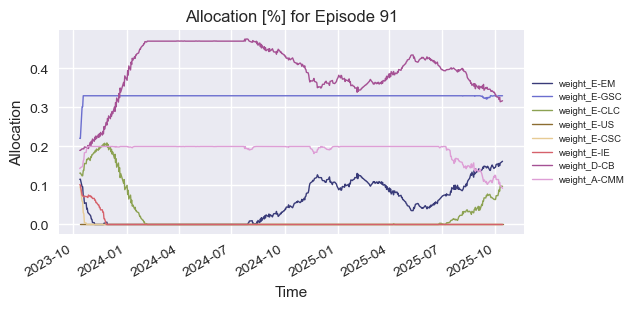

In [122]:
graph_tile = 'Allocation [%] for Episode ' + str(episode_number)
r[weight_list].plot(
    title=graph_tile,
    lw=1,
    cmap='tab20b',
    figsize=(6, 3), # may need this
    grid=True)
plt.legend(loc='center left', fontsize='x-small', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel('Allocation');

#### Testing Episode Asset Correlation
Does the Agent prefer Global Small Cap among the equity sleeves because of how correlated with fixed income (D-CB) and t-bills (A-CMM) it is? That was a pet theory I had, so I decided to indulge myself with a peak at the returns during this episode.

In [124]:
ep_corr_matrix = log_returns[episode_start_date:episode_end_date].corr()
ep_corr_matrix.style.background_gradient(cmap='coolwarm').format(precision=4).set_caption("Episode Asset Correlations")

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM
E-EM,1.0000,0.4999,0.2562,0.2100,0.2514,0.6195,0.0616,-0.0250
E-GSC,0.4999,1.0000,0.5034,0.3652,0.4652,0.7496,0.2356,-0.0048
E-CLC,0.2562,0.5034,1.0000,0.6834,0.8207,0.3551,0.1565,0.0306
E-US,0.2100,0.3652,0.6834,1.0000,0.5779,0.2322,0.1492,0.0178
E-CSC,0.2514,0.4652,0.8207,0.5779,1.0000,0.2589,0.1122,-0.0037
E-IE,0.6195,0.7496,0.3551,0.2322,0.2589,1.0000,0.1696,0.0055
D-CB,0.0616,0.2356,0.1565,0.1492,0.1122,0.1696,1.0000,0.0359
A-CMM,-0.0250,-0.0048,0.0306,0.0178,-0.0037,0.0055,0.0359,1.0000


So the episode correlation between GSC, CB, and CMM may be a factor, but once trained the neural network used by the Agent becomes something of a black box. Fixed Income and Money Market are the two lowest correlations with Global Small Cap however.

## Commentary & Analysis of Testing Episode
The Agent starts at the intuitive weights but then immediately adds more money market instruments which have no volatility then gradually adds bonds selling off their Canadian Large Cap equity. Then after maxing out bonds the Agent gradually lowers the fixed income weight while increasing the Emerging Market equity weight. The Agent based on our training and testing has a *strong preference* for Global Small Cap equity and will almost always max out in this asset class. Eventually the Agent sells some of their t-bills and buys Canadian Large Cap equity which seems to be their second or third favourite equity sleeve. The Agent seems to have a preference for the riskiest and least risky assets classes.

You can also see the Agent becomes more defensive than the weights they started with. Next the Agent gradually takes on more risk by buying more equity then right around Liberation Day (April 10th 2025) the Agent begins increasing their bond allocation and decreasing Emerging Market equity. Finally the Agent again flips and begins buying Emerging Market equity and eventually Canadian Large Cap equity selling off both bonds and t-bills. This seems to be a move to risk on after the volatility of Liberation Day passes, *or perhaps the Agent got lucky?* 

**However, it seems a plausible reaction to market conditions during this period.** It almost seems like the Agent persues a ***Barbell Strategy*** given how the Agent quickly maxes out the bonds and money market allotments. Global Small Cap would also be among the riskier equity asset classes that could be choesen. However, this may be reading too much into the behaviour of the Agent during this episode given it only sees a limited amout of pricing data and has no concept of a Barbell Strategy and is completely oblivious to global economic and political conditions.

### Returns and Standard Deviations
We can examine the returns and standard deviations of the assets and the portfolios in the machine learning episodes.

In [128]:
subset = r[symbol_list_plus_pv]
machine_learning_returns = subset.iloc[-1] / subset.iloc[0] - 1 
machine_learning_returns

E-EM     0.61497
E-GSC    0.11549
E-CLC    0.34446
E-US     0.33449
E-CSC    0.25346
E-IE     0.44357
D-CB     0.08194
A-CMM    0.00000
pv       0.09973
dtype: float64

In [129]:
machine_learning_stdevs = subset.pct_change().std() * math.sqrt(252)
machine_learning_stdevs

E-EM     0.12230
E-GSC    0.12583
E-CLC    0.12189
E-US     0.12746
E-CSC    0.15079
E-IE     0.11442
D-CB     0.05769
A-CMM    0.00000
pv       0.05845
dtype: float64

We can compute the sharpe ratio which is what the agent was trying to optimize for.

In [131]:
machine_learning_returns / machine_learning_stdevs

E-EM     5.02832
E-GSC    0.91789
E-CLC    2.82600
E-US     2.62429
E-CSC    1.68084
E-IE     3.87672
D-CB     1.42029
A-CMM        NaN
pv       1.70637
dtype: float64

As we used prices, the Money Market sleeve never changes price, it does pay a distributions daily *but the agent doesn't know that*. However, the Agent seems to grasp that this is the least volatile asset class and the safest place to park money in a tumultous market. **But the lack of changing prices is why it is NaN.**

#### Graph of Asset and Portfolio Values

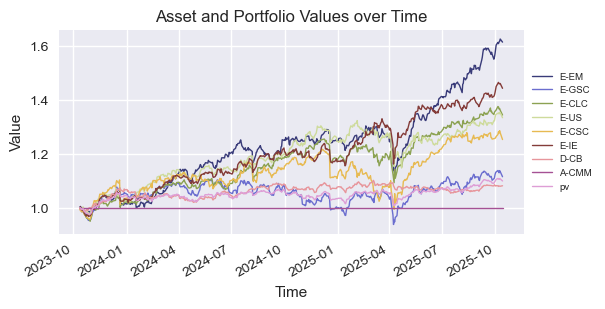

In [134]:
subset.plot(lw=1, 
            title='Asset and Portfolio Values over Time', 
            cmap='tab20b', 
            figsize=(6,3)) 
plt.legend(loc='center left', fontsize='x-small', bbox_to_anchor=(1, 0.5))
plt.ylabel('Value')
plt.xlabel('Time');

### Machine Learning Portfolio vs Benchmark
Let's get some benchmark data to compare with this episode's performance. We need to match it to the start and end of the random episode. We also need to normalize the returns.

In [136]:
cummulative_bm_returns = bm_log_returns[episode_start_date:episode_end_date].cumsum().apply(np.exp) 
cummulative_bm_returns.iloc[-1] # last value

BM    1.40616
Name: 2025-10-14 00:00:00, dtype: float64

In [137]:
cummulative_bm_returns.loc[episode_start_date] # first value

BM    0.99493
Name: 2023-10-12 00:00:00, dtype: float64

In [138]:
cummulative_bm_returns.count()

BM    504
dtype: int64

As some of the benchmark data is monthly, it is possible there are not exactly the same number of benchmark returns as random episode portfolio returns, this is fine when graphing and comparing cummulative returns. Another reason for the difference is the holiday schedule used by MSCI, S&P, Russell etc. So sometimes a benchmark provider will not calculate the benchmark even though a market is open where a firm operates and vice versa.

In [140]:
subset.count().mean()

503.0

#### Now we add the benchmark returns to the episode.

In [142]:
subset['BM'] = cummulative_bm_returns
subset = subset.dropna()
subset.tail()

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM,pv,BM
date,,,,,,,,,,
2025-10-07,1.60943,1.13617,1.37419,1.35178,1.28212,1.46559,1.07942,1.0,1.10691,1.40495
2025-10-08,1.61548,1.13003,1.36679,1.34838,1.27738,1.46051,1.08100,1.0,1.10568,1.40967
2025-10-09,1.61807,1.13815,1.36855,1.35467,1.28635,1.46043,1.08064,1.0,1.10856,1.40650
2025-10-10,1.62637,1.13440,1.36218,1.35318,1.27839,1.46138,1.08011,1.0,1.10761,1.39222
2025-10-14,1.61497,1.11549,1.34446,1.33449,1.25346,1.44357,1.08194,1.0,1.09973,1.40616


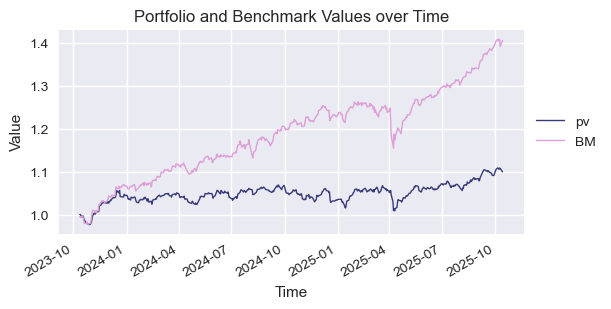

In [143]:
subset[['pv', 'BM']].plot(lw=1, 
                          title='Portfolio and Benchmark Values over Time', 
                          cmap='tab20b',
                          figsize=(6,3))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Value')
plt.xlabel('Time');

As well as the Agent did managing the portfolio during a very difficult period in recent market conditions, **the Agent still failed to beat the benchmark.** Even doing twenty times as much training the Agent still struggles to beat the benchmark, so the neural network would benefit from additional hyperparameter tuning.

### Testing Episode Sharpe Ratios
Let's take a closer look at the sharpe ratios of the testing episodes. As you can see Episode 91 is the most succesful episode in maximizing the portfolio's Sharpe Ratio.

In [146]:
sharpe_ratios = pd.DataFrame()

In [147]:
calculate_sr()

In [148]:
sharpe_ratios.round(2)

,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
E-EM,-1.70,0.68,3.46,2.18,1.76,-0.34,1.77,1.53,3.81,2.79,5.03,1.73,-1.42,2.35,1.64,1.55,0.26,-0.51,0.18,2.33
E-GSC,-1.79,-0.04,0.50,1.22,0.88,-0.49,0.83,0.87,0.63,1.12,0.92,0.85,-1.65,1.17,0.81,0.68,0.16,-0.39,0.28,1.50
E-CLC,0.73,0.51,2.30,1.03,0.61,2.70,0.73,0.53,2.59,0.48,2.83,0.53,-0.39,0.12,1.08,0.72,0.64,0.56,0.64,0.25
E-US,0.39,1.69,2.30,1.76,1.32,1.76,1.47,1.42,2.09,1.64,2.62,1.34,0.25,1.86,1.75,1.27,2.16,1.47,2.21,2.22
E-CSC,-0.55,-0.21,1.12,2.25,1.22,1.44,1.95,1.93,1.38,1.58,1.68,1.94,-1.60,0.13,2.08,1.71,0.98,0.51,0.39,0.24
E-IE,-1.54,0.03,2.92,1.82,1.11,0.01,1.25,1.17,3.11,1.66,3.88,1.02,-1.16,2.02,1.38,1.05,-0.01,-0.21,0.33,2.57
D-CB,-3.61,-0.25,0.51,-0.59,2.03,-2.92,-0.29,-0.09,0.71,0.60,1.42,-0.16,-2.14,-0.51,-0.51,-0.30,0.53,2.06,0.81,0.11
A-CMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pv,-1.79,-0.01,1.33,0.58,0.46,-1.39,-0.00,-0.15,1.33,0.23,1.71,-0.10,-1.73,0.35,-0.21,-0.08,0.28,0.21,0.50,0.85


Again because there is no change in price for the Money Market sleeve as there is no return or standard deviation in the investing environement, hence the NaN.

#### Average Sharpe Ratio

In [151]:
sharpe_ratios.mean(axis=1)

E-EM     1.45467
E-GSC    0.40424
E-CLC    0.95834
E-US     1.65050
E-CSC    1.00784
E-IE     1.12085
D-CB    -0.12933
A-CMM        NaN
pv       0.11813
dtype: float64

## Who wants to be average?
Average is fine, but given we know the best episode for the Agent managing the portfolio in terms of maximizing the Sharpe ratio, lets get that asset allocation too.

In [153]:
episode_with_best_sharpe = sharpe_ratios.idxmax(axis=1)['pv'] 
print(episode_with_best_sharpe)
r_best = get_r(episode_with_best_sharpe)
r_best[weight_list].iloc[-1].round(2)

91.0


weight_E-EM     0.16
weight_E-GSC    0.33
weight_E-CLC    0.10
weight_E-US     0.00
weight_E-CSC    0.00
weight_E-IE     0.00
weight_D-CB     0.32
weight_A-CMM    0.09
Name: 2025-10-14 00:00:00, dtype: float64

#### Why use mean weights?
Because the agent tends towards the extreme ends of the bounds and the trading cost and administrative overhead of rebalancing daily is higher than people think, using an average to summarize a training Episode makes sense. Even applying penalties and enforcing boundaries the Agent trades frequently. Taking the average asset weight is a more realisitic snapshot than the last weight at the end of a training or testing Episode, but you can try either by changing the line of code below.

In the end I decided to take both the last weights of the best testing Episode and the average machine learning weights saving both to variables.

In [155]:
best_weights = r_best[weight_list].iloc[-1]  # Don't round here. Can try either .mean() or .iloc[-1]

In [156]:
last_best_ml_weights = tuple(best_weights.to_list()) 
training_portfolios.dataframe_for_weights(last_best_ml_weights)

,Weight
Asset,
E-EM,1.62091e-01
E-GSC,3.30000e-01
E-CLC,9.79559e-02
E-US,7.65204e-18
E-CSC,0.00000e+00
E-IE,4.08429e-18
D-CB,3.17175e-01
A-CMM,9.27784e-02


## Testing Our Portfolios
Now that we've calculated mathematically precise mean-variance portfolios using a variety of means we can test them using the teasting data we set aside earlier.

In [158]:
symbols = testing_asset_returns.columns 
portfolio_name = str(last_year) + ' Efficient Portfolio'
testing_portfolios = MVPortfolio(bm_returns=bm_testing_returns,
                                 comparison_weights_one=ml_average_weights,
                                 portfolio_one_name='Average ML Weights',
                                 comparison_weights_two=maximum_sharpe_weights,
                                 portfolio_two_name='Training Period Efficient Portfolio',
                                 comparison_weights_three=last_training_years_optimal_weights,
                                 portfolio_three_name=portfolio_name,
                                 comparison_weights_four=last_best_ml_weights,
                                 portfolio_four_name='Last Best ML Weights',
                                 comparison_weights_five=portfolio_five_weights,
                                 portfolio_five_name=portfolio_five_name,
                                 boundaries=bnds_used_in_training,
                                 universe=testing_asset_returns,
                                 holdings=symbols
                                )

Remember target asset class weights [0.6, 0.4, 0.0] can be overruled by bnds.
Current bnds are ((0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.19, 0.6), (0.01, 0.2))


### Visualizing and Testing Our Portfolios

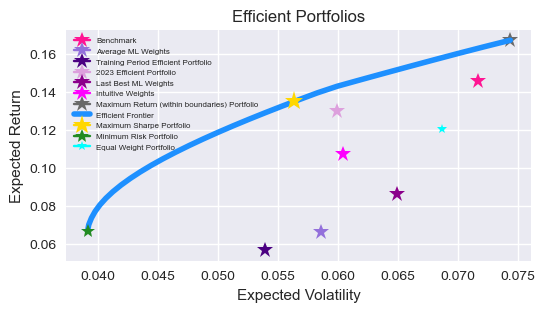

In [160]:
testing_portfolios.visualize_efficient_frontier() 

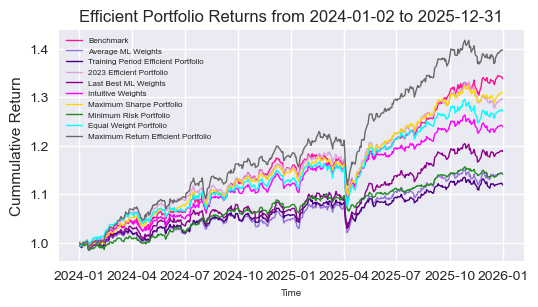

In [161]:
testing_portfolios.visualize_portfolio_returns()

## Testing Period Summary
The benchmark did very well over this period of time, it is not unbeatable but you must take on a lot of volatility to exceed the performance of the benchmark. Outside the training period the machine learning weights did not perform well but neither did the Maximum Sharpe Portfolio from the training period which I labeled "Training Period Efficient Portfolio". The "2023 Efficient Portfolio" did better and even beat the equal weight portfolio by both being closer to the efficient frontier and having a greater cummulative return.

### Takeaways
- Training period performance or **past performance is no guarantee of future performance**.
- It is very difficult to beat a well chosen benchmark even with frequent rebalancing based on machine learning.
- If you are willing to take on more volatility it is possible to achieve higher than benchmark returns.

#### Maximum Sharpe Portfolio during the Testing Period

In [164]:
testing_maximum_return_weights = testing_portfolios.maximum_return_portfolio()
testing_portfolios.dataframe_for_weights(testing_maximum_return_weights)

,Weight
Asset,
E-EM,3.30000e-01
E-GSC,1.12022e-16
E-CLC,3.30000e-01
E-US,2.11564e-16
E-CSC,7.85608e-17
E-IE,1.40000e-01
D-CB,1.90000e-01
A-CMM,1.00000e-02


During the testing period you wanted to max out Emerging Market equity which is one of our best performing equity portfolios. Canadian Large Cap equity is also maxed out. As the last two years have arguably been a bull market a minimum allocation to bonds and t-bills was optimal. International equity is another equity portfolio that has performed well recently and historically at the firm.

#### About Diversification
The above portfolio is more diversified than it may first appear. Each equity asset class sleeve is managed by an individual team and consists of on average fifty plus holdings. The bond and money market sleeve are similarly diverse. So putting a maximum weight into a sleeve is not the same as investing it all into a single security. Furthermore an asset class such as Emerging Market equity will have zero common holdings with say Canadian Large Cap equity which are the two maxed out sleeves in the testing period.

## Entire Period
Let's see how the average machine learning weights do against the classic balanced portfolios over the entire data set.

In [168]:
symbols = log_returns.columns 
final_portfolios = MVPortfolio(
                                bm_returns=bm_log_returns,
                                comparison_weights_one=portfolio_one_weights,
                                portfolio_one_name=portfolio_one_name,
                                comparison_weights_two=portfolio_two_weights,
                                portfolio_two_name=portfolio_two_name,
                                comparison_weights_three=portfolio_three_weights,
                                portfolio_three_name=portfolio_three_name,
                                comparison_weights_four=portfolio_four_weights,
                                portfolio_four_name=portfolio_four_name,
                                comparison_weights_five=ml_average_weights,
                                portfolio_five_name='Average ML Weights',
                                boundaries=bnds_used_in_training,
                                universe=log_returns,
                                holdings=symbols
                               )

Remember target asset class weights [0.6, 0.4, 0.0] can be overruled by bnds.
Current bnds are ((0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.19, 0.6), (0.01, 0.2))


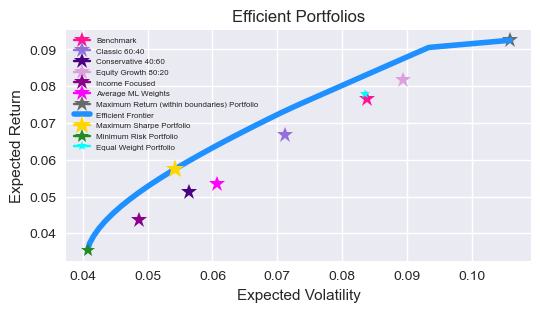

In [169]:
final_portfolios.visualize_efficient_frontier() 

### Return Distribution
As you can see the more equity you have in your portfolio the better your expected return but the greater your expected volatility. It actually looks like the equal weight portfolio beats the benchmark over the entire period, this portfolio has 12.5% bonds and 12.5% money market instruments so less than the benchmark weights. The Classic 60:40 portfolio has a greater expected return than the Maximum Sharpe Portfolio which is perhaps why it is preferred over a mathematically maximal Sharpe Ratio portfolio. The more training episodes you run the better the Average ML Weights portfolio seems to do, however we are constrained by fifteen minutes of cloud compute in this demonstration. That said I tested doing over 1600 training episodes and beating the benchmark is difficult for the machine learnign algorithm with the current design and hyperparameters.

### Summary of Data
With this final summation `dataframe` it is easy to save your work to a file or continue doing further analysis.

In [286]:
summary_df = final_portfolios.summary()
summary_df.T.sort_values(by='Annualized Sharpe Ratio', ascending=False).T.round(3)

,Maximum Sharpe Portfolio,Classic 60:40,Equal Weight Portfolio,Equity Growth 80:20,Conservative 40:60,Income Focused,Average ML Weights,Maximum Return Efficient Portfolio,Minimum Risk Portfolio
Annualized Return,0.057,0.067,0.078,0.082,0.051,0.044,0.053,0.093,0.035
Annualized Volatility,0.054,0.071,0.083,0.089,0.056,0.049,0.061,0.106,0.041
Annualized Sharpe Ratio,1.060,0.937,0.932,0.914,0.905,0.898,0.878,0.874,0.868
E-EM,0.120,0.100,0.125,0.133,0.066,0.050,0.038,0.000,0.085
E-GSC,0.000,0.100,0.125,0.133,0.066,0.050,0.329,0.000,0.008
E-CLC,0.018,0.100,0.125,0.133,0.066,0.050,0.124,0.330,0.074
E-US,0.159,0.100,0.125,0.133,0.066,0.050,0.000,0.330,0.009
E-CSC,0.000,0.100,0.125,0.133,0.066,0.050,0.001,0.000,0.002
E-IE,0.133,0.100,0.125,0.133,0.066,0.050,0.009,0.140,0.023
D-CB,0.370,0.390,0.125,0.190,0.590,0.600,0.323,0.190,0.600


You could calculate the mean weight allocated to bonds as this is one of the key investing decisions a person or a machine learning Agent can make. The averge is less than 40% during this demonstration and time period.

In [174]:
summary_df.T['D-CB'].mean()

0.37529809245404266

You can quickly graph the asset allocations, though I cheated a bit and brought in `seaborn` to make a fancy looking graph with one line of code, you can make a similar graph with `matplotlib` changing `sns` to `plt` and `data` to `dataset` *but it doesn't look as good*.

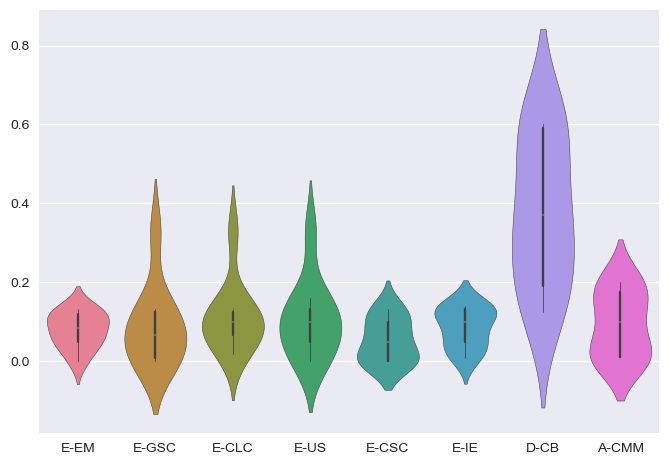

In [293]:
sns.violinplot(data=summary_df.T[symbols]);

Global Small Cap, Canadian Large Cap and US Large Cap equity are the three most popular equity asset class and there is probalby zero overlap among the securities held in those portfolios, are they the least correlated equity asset classes?

In [296]:
eq_corr_matrix = log_returns[['E-GSC', 'E-CLC', 'E-US']].corr()
eq_corr_matrix.style.background_gradient(cmap='coolwarm').format(precision=4).set_caption("Select Asset Correlations")

,E-GSC,E-CLC,E-US
E-GSC,1.0000,0.6180,0.5328
E-CLC,0.6180,1.0000,0.7354
E-US,0.5328,0.7354,1.0000


They are positively correlated because they are all equity asset clases. Refining the boundaries and the initial allocations of the comparative balanced portfolios will yield different results for the non-algorithmatically created portfolios.

# Conclusions
Although the Investing Agent was not able to beat the benchmark, it is still possible given the input data to construct a mean-variance efficient portfolio that will beat the benchmark while staying in the boundaries of a balanced portfolio. However, it is necessary to take on more risk in the form of a higher than 60% equity allocation or to min-max your equity allocation. The investing Agent seems to prefer a higher allocation to the least risky asset Canadian T-Bills than any other allocation strategy which of course lowers overall volatility and achieves the goal of maximizing Sharpe Ratio.

## Future Improvements
There are a number of obvious improvements that were either beyond the scope of the class project such as connecting to a database or API to source pricing and returns data or were adjacent to the core expirement, such as additional risk metrics which may have proven illuminating. The plot of the efficient frontier clearly shows that taking on more risk in the form of a greater allocation to equity lowers overall Sharpe Ratio but it increases portfolio returns so this may be a tradeoff many clients are willing to make. Maximizing return wasn't what the Agent was seeking to do, to that end I recommend switching to the Information Ratio:

$$\text{Information Ratio (IR)} = \frac{R_p - R_b}{\sigma_{p-B}}$$

Making this single change would make a benchmark mandatory and the reward given to the Investing Agent would be lessened the better the benchmark performed forcing the Agent to allocate assets more aggressively. To switch to Information Ratio would require modifying several methods and retesting and retunning the the Deep Q-Learning Agent. Just changing the boundaries would prevent the Agent from going from 80% Equity to 20% Equity, but altering the reward the Agent receives may incentivise the Agent to invest more aggresively when they feel the timing is optimal to take on more risk.

The project requirements specified a Jupyter notebook, but end users may prefer a graphical user interface. Switching to `plotly` for interactive plotting may also be more user-friendly. Finally as training and tunning the Deep Q-Learning Agent is a significant investment of time, saving the `pytorch` `model` after it is trained and tuned seems adviseable.